# Complete K-Means Evaluation Framework  
## All Seven Features, K = 2 to K = 10

### Purpose

This notebook evaluates K-Means solutions from **K=2 to K=10** using all seven selected customer features:

- Recency
- Frequency
- Monetary
- Average Order Value
- Basket Size
- Product Diversity
- Total Quantity

The notebook does not assume that one metric alone can identify the final number of clusters. It evaluates each candidate using:

1. WCSS/Inertia and percentage reduction in WCSS.
2. Silhouette Score.
3. Davies–Bouldin Index.
4. Calinski–Harabasz Index.
5. Random-seed stability using Adjusted Rand Index.
6. Repeated 80% subsampling stability.
7. Cluster-size feasibility.
8. Per-cluster silhouette quality.
9. Original-scale mean and median profiles.
10. Exploratory Kruskal–Wallis tests with effect sizes.
11. Behavioural and business interpretation.

The notebook reports the statistically strongest solution as the **statistical benchmark**. It separately reviews K=2, K=3, K=4 and K=5 as candidate solutions. K=5 is treated as the **operational candidate**, not as an automatic statistical winner.

## 1. Import libraries

In [ ]:
import os
import json
import shutil
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define files, model settings and output folders


In [ ]:
PROCESSED_FILE = "/content/customer_features_processed.csv"

RAW_FILE_CANDIDATES = [
    "/content/customer_features_ready_for_preprocessing.csv",
    "/content/customer_features_raw.csv"
]

RAW_FILE = next(
    (path for path in RAW_FILE_CANDIDATES if os.path.exists(path)),
    RAW_FILE_CANDIDATES[0]
)

RESULTS_DIR = Path("/content/KMeans_Complete_Evaluation_Updated_Results")
TABLES_DIR = RESULTS_DIR / "Tables"
FIGURES_DIR = RESULTS_DIR / "Figures"
MODELS_DIR = RESULTS_DIR / "Models"
DATASETS_DIR = RESULTS_DIR / "Clustered_Datasets"
PROFILES_DIR = RESULTS_DIR / "Cluster_Profiles"
STABILITY_DIR = RESULTS_DIR / "Stability"
CANDIDATE_DIR = RESULTS_DIR / "Candidate_Comparison"

for folder in [
    RESULTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    DATASETS_DIR,
    PROFILES_DIR,
    STABILITY_DIR,
    CANDIDATE_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS = [
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue",
    "BasketSize",
    "ProductDiversity",
    "TotalQuantity"
]

K_VALUES = list(range(2, 11))
CANDIDATE_K_VALUES = [2, 3, 4, 5]

BASELINE_RANDOM_STATE = 42
BASELINE_N_INIT = 50
MAX_ITER = 500

SEED_VALUES = list(range(1, 31))
SUBSAMPLE_RUNS = 50
SUBSAMPLE_FRACTION = 0.80
SUBSAMPLE_RANDOM_STATE = 2026

MINIMUM_PRACTICAL_CLUSTER_PERCENTAGE = 5.0
OPERATIONAL_K = 5

print("K values:", K_VALUES)
print("Detailed candidates:", CANDIDATE_K_VALUES)
print("Output folder:", RESULTS_DIR)

K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]
Detailed candidates: [2, 3, 4, 5]
Output folder: /content/KMeans_Complete_Evaluation_Updated_Results


## 3. Load the datasets

In [ ]:
if not os.path.exists(PROCESSED_FILE):
    raise FileNotFoundError(
        f"Processed dataset not found: {PROCESSED_FILE}"
    )

if not os.path.exists(RAW_FILE):
    raise FileNotFoundError(
        "Original-scale customer feature dataset was not found."
    )

processed_data = pd.read_csv(PROCESSED_FILE)
raw_data = pd.read_csv(RAW_FILE)

print("=" * 80)
print("DATASETS LOADED")
print("=" * 80)

print("\nProcessed dataset shape:", processed_data.shape)
print("Original-scale dataset shape:", raw_data.shape)

print("\nProcessed preview:")
display(processed_data.head())

print("\nOriginal-scale preview:")
display(raw_data.head())

DATASETS LOADED

Processed dataset shape: (4338, 8)
Original-scale dataset shape: (4338, 9)

Processed preview:


,CustomerID,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,12346,2.2177,-0.3691,2.8139,6.3667,5.7289,-1.8972,2.8943
1,12347,-0.3952,0.8928,1.1038,0.8503,0.7260,0.6963,1.0256
2,12348,0.1935,0.4650,0.5856,0.4911,1.2025,-0.2941,0.9989
3,12349,-0.2581,-0.3691,0.5723,2.0472,1.2728,0.4730,0.2805
4,12350,2.0887,-0.3691,-0.4098,0.1546,0.1876,-0.4550,-0.3561



Original-scale preview:


,CustomerID,Recency,Frequency,Monetary,TotalQuantity,ProductDiversity,TransactionCount,AverageOrderValue,BasketSize
0,12346,326,1,"77,183.6000",74215,1,1,"77,183.6000","74,215.0000"
1,12347,2,7,"4,310.0000",2458,103,182,615.7100,351.1400
2,12348,75,4,"1,797.2400",2341,22,31,449.3100,585.2500
3,12349,19,1,"1,757.5500",631,73,73,"1,757.5500",631.0000
4,12350,310,1,334.4000,197,17,17,334.4000,197.0000


## 4. Validate and align the datasets

In [ ]:
required_columns = ["CustomerID"] + FEATURE_COLUMNS

missing_processed = [
    column for column in required_columns
    if column not in processed_data.columns
]

missing_raw = [
    column for column in required_columns
    if column not in raw_data.columns
]

if missing_processed:
    raise ValueError(
        f"Missing processed columns: {missing_processed}"
    )

if missing_raw:
    raise ValueError(
        f"Missing original-scale columns: {missing_raw}"
    )

if processed_data["CustomerID"].duplicated().any():
    raise ValueError(
        "Duplicate CustomerID values found in processed data."
    )

if raw_data["CustomerID"].duplicated().any():
    raise ValueError(
        "Duplicate CustomerID values found in original-scale data."
    )

if processed_data[required_columns].isnull().sum().sum() > 0:
    raise ValueError(
        "Missing values found in processed clustering data."
    )

if raw_data[required_columns].isnull().sum().sum() > 0:
    raise ValueError(
        "Missing values found in original-scale data."
    )

raw_data = (
    processed_data[["CustomerID"]]
    .merge(
        raw_data[required_columns],
        on="CustomerID",
        how="left",
        validate="one_to_one"
    )
)

if raw_data.isnull().sum().sum() > 0:
    raise ValueError(
        "CustomerID alignment failed between datasets."
    )

if not np.array_equal(
    processed_data["CustomerID"].to_numpy(),
    raw_data["CustomerID"].to_numpy()
):
    raise ValueError(
        "Customer ordering is not aligned."
    )

X = processed_data[FEATURE_COLUMNS].copy()

if not np.isfinite(X.to_numpy()).all():
    raise ValueError(
        "Infinite or non-finite values found in clustering features."
    )

print("=" * 80)
print("INPUT VALIDATION COMPLETED")
print("=" * 80)

print("Customers:", len(X))
print("Features:", len(FEATURE_COLUMNS))
display(X.describe().T)

INPUT VALIDATION COMPLETED
Customers: 4338
Features: 7


,count,mean,std,min,25%,50%,75%,max
Recency,"4,338.0000",0.3350,0.8066,-0.4032,-0.2661,0.0000,0.7339,2.6048
Frequency,"4,338.0000",0.2248,0.6218,-0.3691,-0.3691,0.0000,0.6309,3.8671
Monetary,"4,338.0000",0.0486,0.7459,-2.9331,-0.4613,-0.0000,0.5387,3.5781
AverageOrderValue,"4,338.0000",-0.0388,0.8516,-4.7825,-0.5635,0.0000,0.4365,6.4666
BasketSize,"4,338.0000",-0.0439,0.8450,-4.1088,-0.5189,0.0000,0.4811,5.7289
ProductDiversity,"4,338.0000",-0.0210,0.7427,-1.8972,-0.4925,0.0000,0.5075,2.5634
TotalQuantity,"4,338.0000",0.0239,0.7517,-2.8763,-0.4730,0.0000,0.5270,3.4295


## 5. excluded columns

`CustomerID` is excluded because it is an identifier and does not represent customer behaviour.

If `TransactionCount` or other audit columns exist in the processed file, they are excluded from clustering because the final feature set was defined before model evaluation. In particular, a transaction-count field may overlap with Frequency and could give purchasing activity additional weight.

In [ ]:
excluded_columns = [
    column for column in processed_data.columns
    if column not in ["CustomerID"] + FEATURE_COLUMNS
]

excluded_column_report = pd.DataFrame({
    "Excluded_Column": excluded_columns,
    "Reason": [
        (
            "Not part of the final seven-feature clustering matrix; "
            "retained only for audit, reference or redundancy control."
        )
        for _ in excluded_columns
    ]
})

print("Columns used for clustering:")
print(FEATURE_COLUMNS)

print("\nOther processed columns excluded from clustering:")
display(excluded_column_report)

excluded_column_report.to_csv(
    TABLES_DIR / "excluded_columns_report.csv",
    index=False
)

Columns used for clustering:
['Recency', 'Frequency', 'Monetary', 'AverageOrderValue', 'BasketSize', 'ProductDiversity', 'TotalQuantity']

Other processed columns excluded from clustering:


,Excluded_Column,Reason


## 6. Review feature correlations


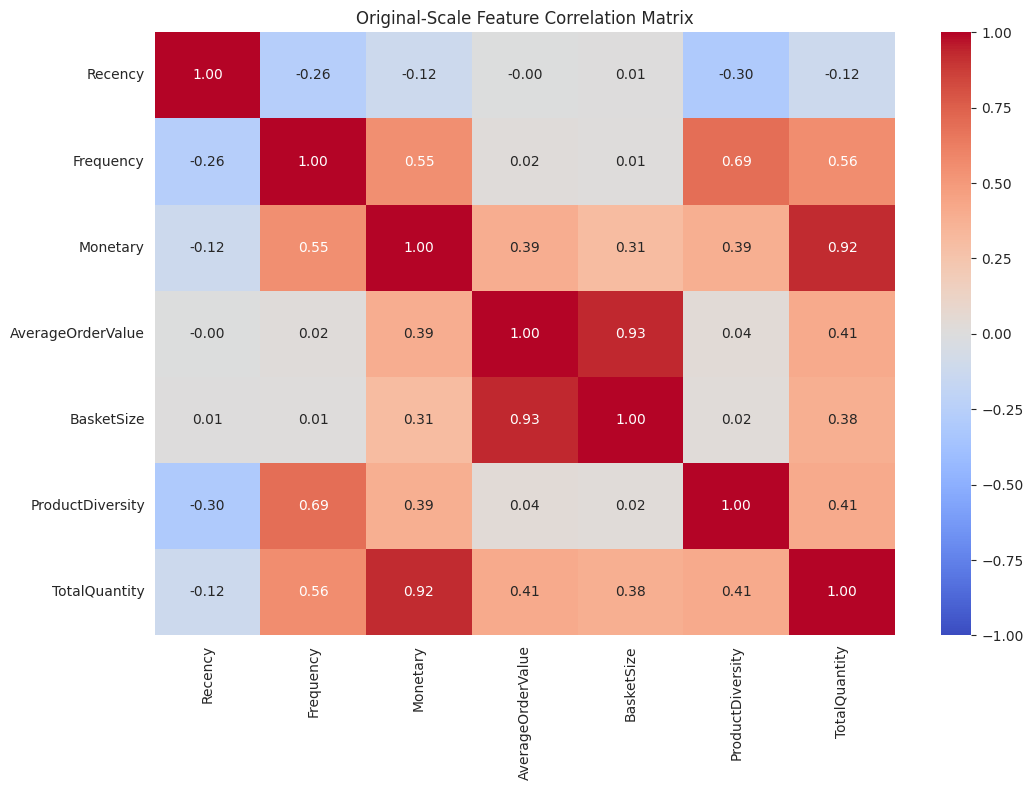

Feature pairs with absolute correlation of at least 0.70:


,Feature_1,Feature_2,Correlation,Absolute_Correlation
0,AverageOrderValue,BasketSize,0.9309,0.9309
1,Monetary,TotalQuantity,0.9229,0.9229


In [ ]:
correlation_matrix = raw_data[FEATURE_COLUMNS].corr(method="pearson")

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Original-Scale Feature Correlation Matrix")
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "feature_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

correlation_matrix.to_csv(
    TABLES_DIR / "feature_correlation_matrix.csv"
)

strong_pairs = []

for row_index, first_feature in enumerate(FEATURE_COLUMNS):
    for second_feature in FEATURE_COLUMNS[row_index + 1:]:
        correlation = correlation_matrix.loc[
            first_feature,
            second_feature
        ]

        if abs(correlation) >= 0.70:
            strong_pairs.append({
                "Feature_1": first_feature,
                "Feature_2": second_feature,
                "Correlation": correlation,
                "Absolute_Correlation": abs(correlation)
            })

strong_correlation_pairs = pd.DataFrame(strong_pairs)

if not strong_correlation_pairs.empty:
    strong_correlation_pairs = (
        strong_correlation_pairs
        .sort_values(
            "Absolute_Correlation",
            ascending=False
        )
        .reset_index(drop=True)
    )

print("Feature pairs with absolute correlation of at least 0.70:")
display(strong_correlation_pairs)

strong_correlation_pairs.to_csv(
    TABLES_DIR / "strong_feature_correlations.csv",
    index=False
)

## 7. Create a common PCA visualisation space



In [ ]:
pca = PCA(
    n_components=2,
    random_state=BASELINE_RANDOM_STATE
)

pca_coordinates = pca.fit_transform(X)

pca_base = pd.DataFrame({
    "CustomerID": processed_data["CustomerID"],
    "PC1": pca_coordinates[:, 0],
    "PC2": pca_coordinates[:, 1]
})

pca_variance = pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Explained_Variance_Ratio": (
        pca.explained_variance_ratio_
    ),
    "Explained_Variance_Percentage": (
        pca.explained_variance_ratio_ * 100
    )
})

display(pca_variance)

pca_variance.to_csv(
    TABLES_DIR / "pca_explained_variance.csv",
    index=False
)

,Component,Explained_Variance_Ratio,Explained_Variance_Percentage
0,PC1,0.6156,61.5640
1,PC2,0.1980,19.8007


## 8. Helper functions

In [ ]:
def build_kmeans(k, random_state):
    return KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=BASELINE_N_INIT,
        max_iter=MAX_ITER,
        random_state=random_state,
        algorithm="lloyd"
    )


def create_cluster_size_table(labels, k):
    table = (
        pd.Series(labels, name="Cluster")
        .value_counts()
        .sort_index()
        .reindex(range(k), fill_value=0)
        .rename_axis("Cluster")
        .reset_index(name="Customer_Count")
    )

    table["Customer_Percentage"] = (
        table["Customer_Count"]
        / table["Customer_Count"].sum()
        * 100
    )

    return table


def create_silhouette_summary(labels, silhouette_values, k):
    data = pd.DataFrame({
        "Cluster": labels,
        "Silhouette_Value": silhouette_values
    })

    summary = (
        data.groupby("Cluster")["Silhouette_Value"]
        .agg(
            Customer_Count="count",
            Mean_Silhouette="mean",
            Median_Silhouette="median",
            Minimum_Silhouette="min",
            Maximum_Silhouette="max",
            Standard_Deviation="std"
        )
        .reindex(range(k))
        .reset_index()
    )

    negative_counts = (
        data.assign(
            Is_Negative=data["Silhouette_Value"] < 0
        )
        .groupby("Cluster")["Is_Negative"]
        .sum()
        .reindex(range(k), fill_value=0)
        .reset_index(
            name="Negative_Silhouette_Customers"
        )
    )

    summary = summary.merge(
        negative_counts,
        on="Cluster",
        how="left"
    )

    summary["Negative_Silhouette_Percentage"] = (
        summary["Negative_Silhouette_Customers"]
        / summary["Customer_Count"]
        * 100
    )

    return summary


def epsilon_squared_kruskal(h_statistic, n, number_of_groups):
    denominator = n - number_of_groups

    if denominator <= 0:
        return np.nan

    effect_size = (
        h_statistic - number_of_groups + 1
    ) / denominator

    return max(0.0, min(1.0, effect_size))

## 9. Fit and evaluate K-Means for every K

For each value of K, this section:

- trains a baseline model;
- calculates internal validation metrics;
- saves the model and customer assignments;
- creates mean, median and standard-deviation profiles;
- calculates per-cluster silhouette results;
- tests 30 random seeds;
- tests 50 repeated 80% customer subsamples;
- analyses cluster-size feasibility;
- saves PCA, silhouette and profile figures.


All the figures are saved.

To reduce notebook Size, i displayed the detailed plots only for K=2, K=3, K=4 and K=5.


PROCESSING K = 2


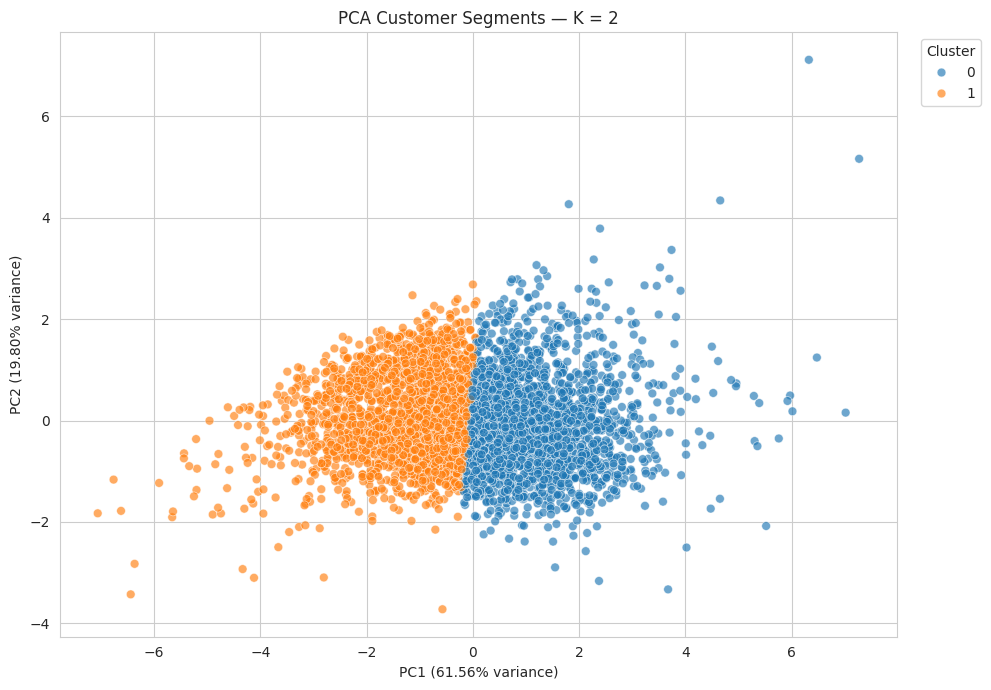

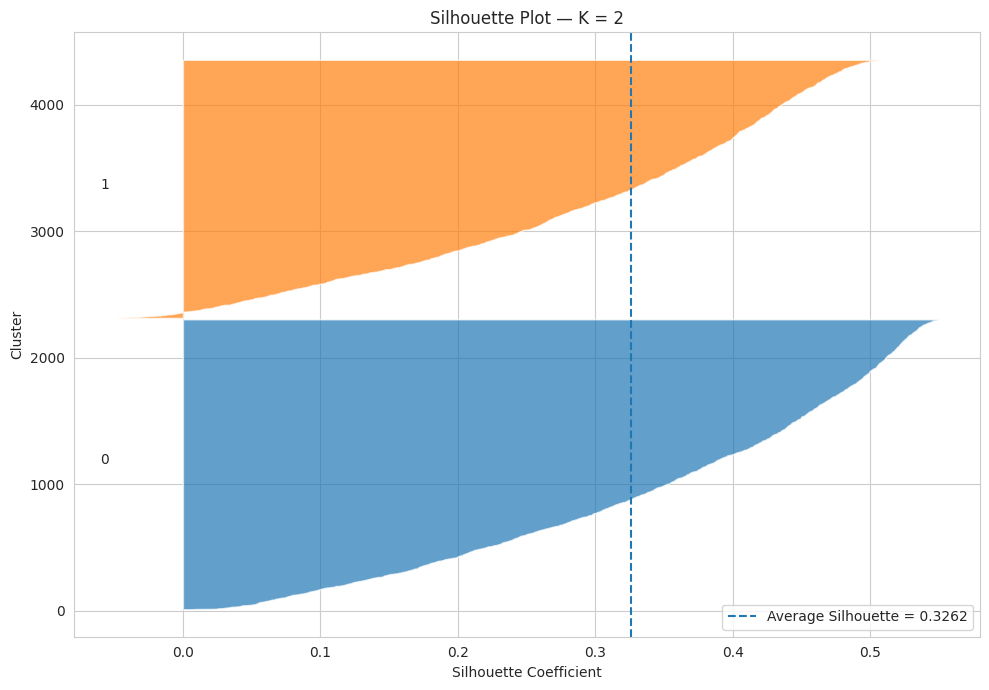

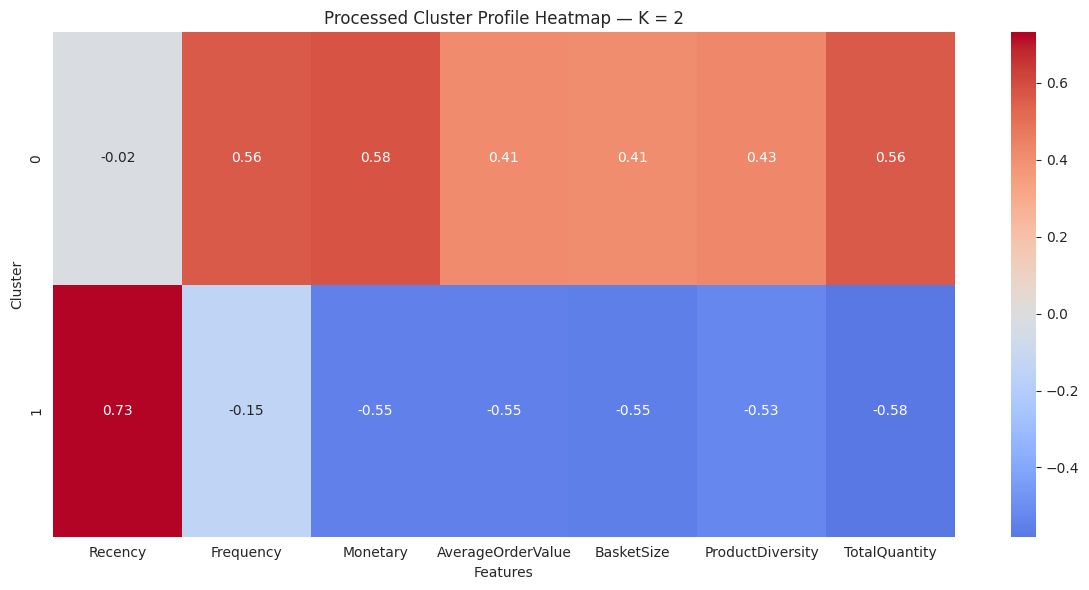

K=2 completed | Silhouette=0.3262 | DBI=1.1444 | CH=2692.53

PROCESSING K = 3


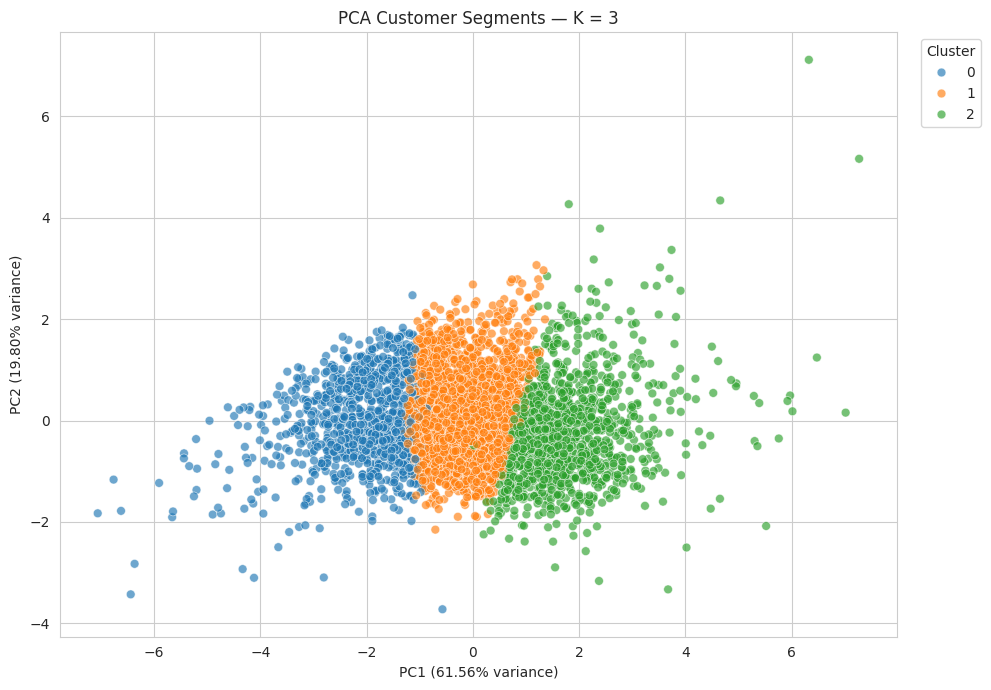

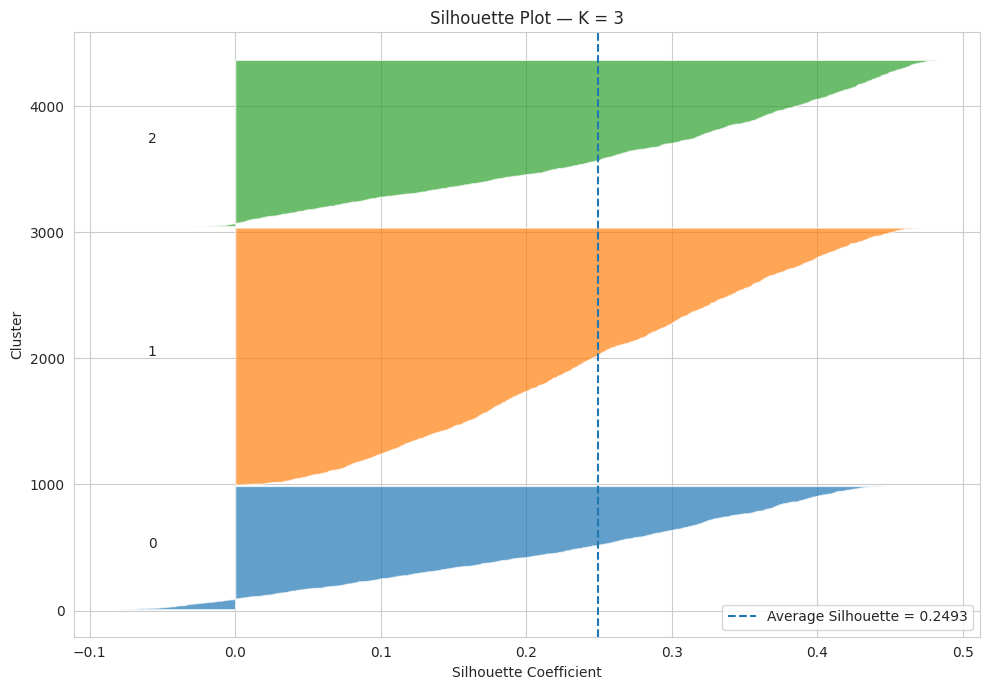

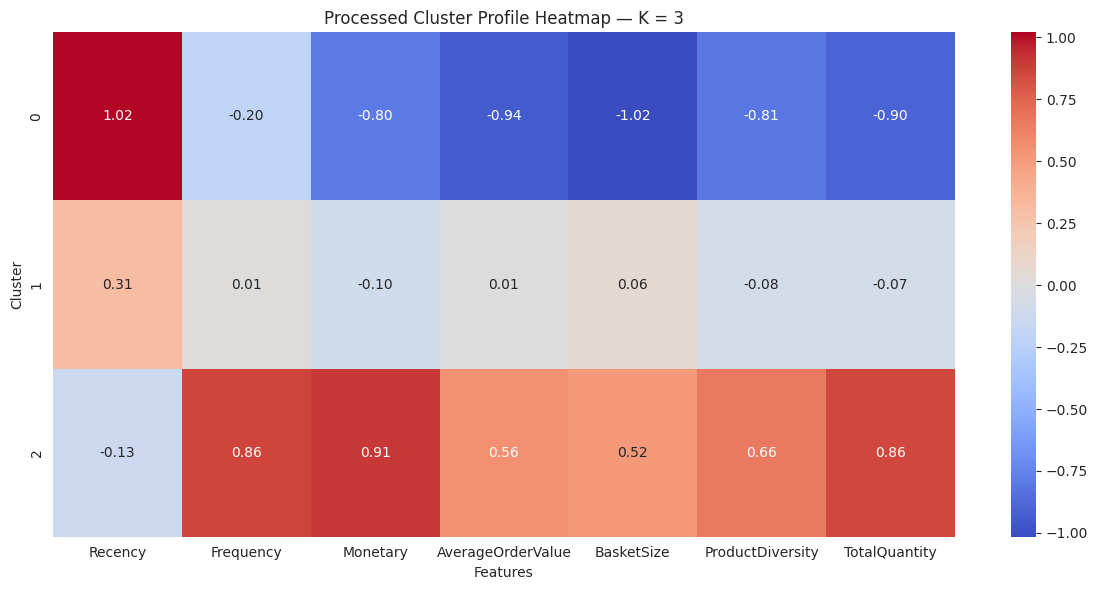

K=3 completed | Silhouette=0.2493 | DBI=1.2964 | CH=2121.78

PROCESSING K = 4


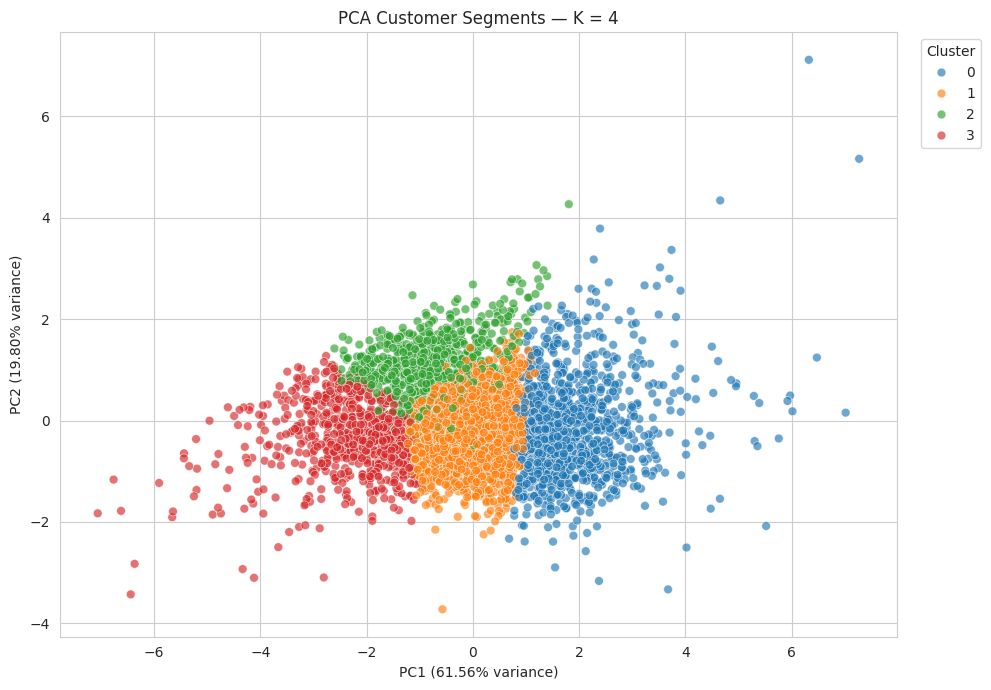

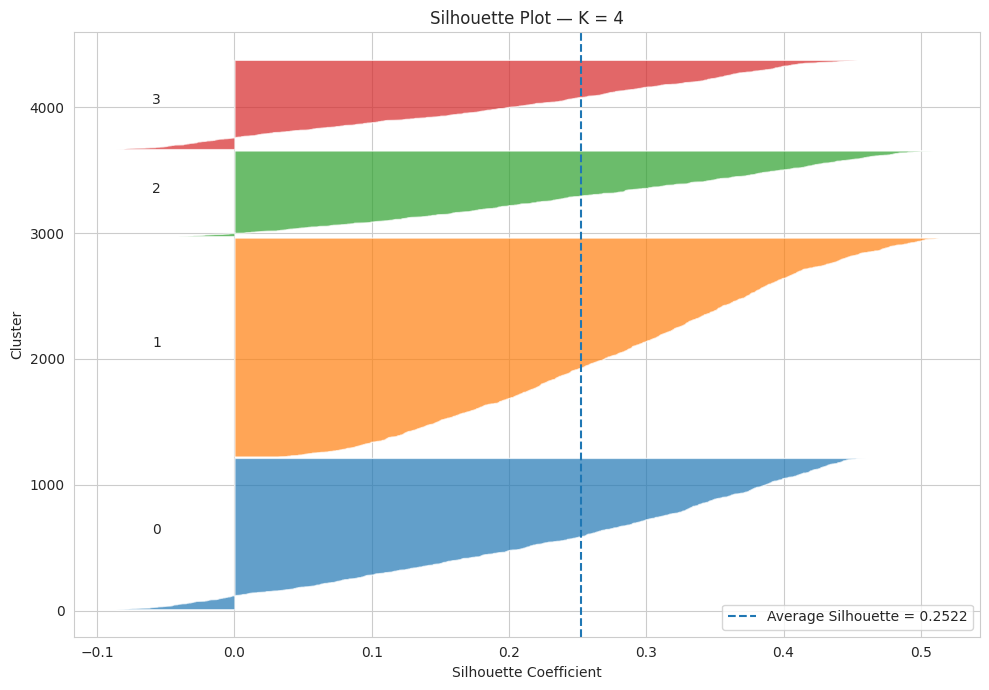

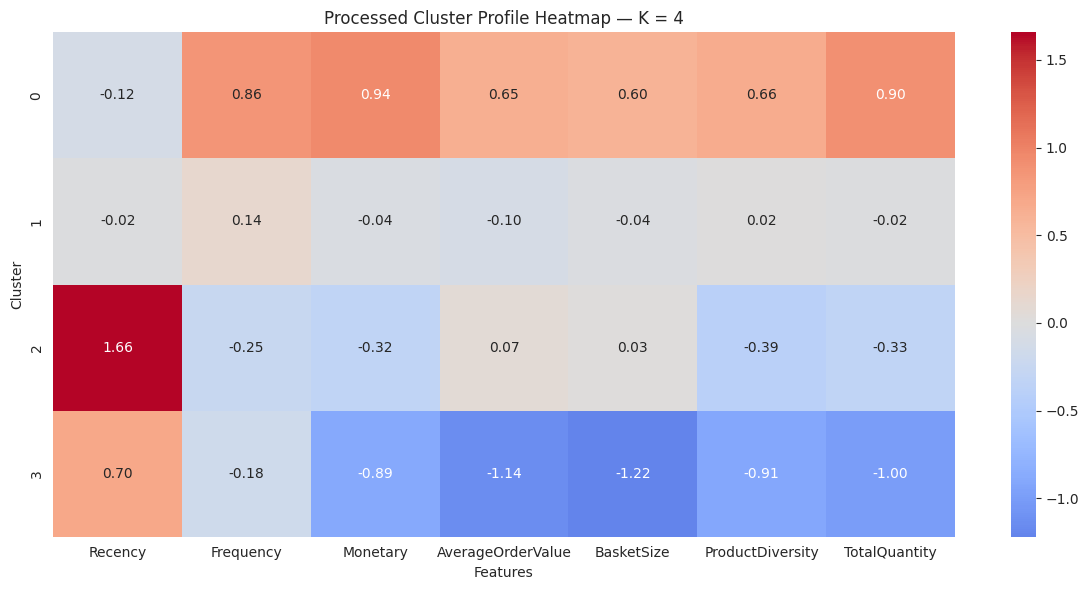

K=4 completed | Silhouette=0.2522 | DBI=1.2088 | CH=1862.81

PROCESSING K = 5


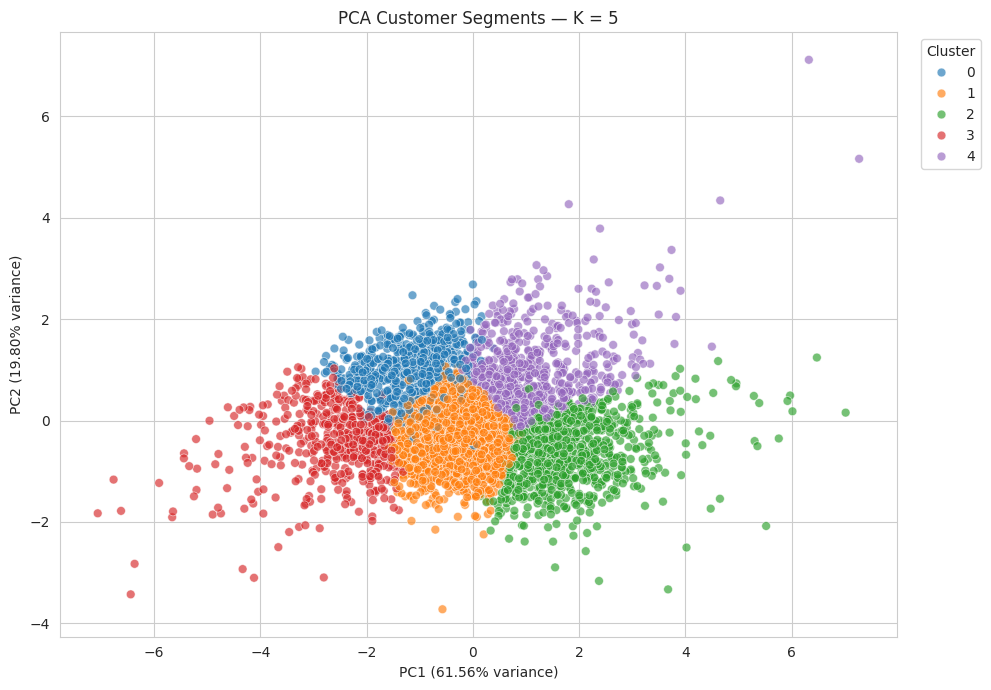

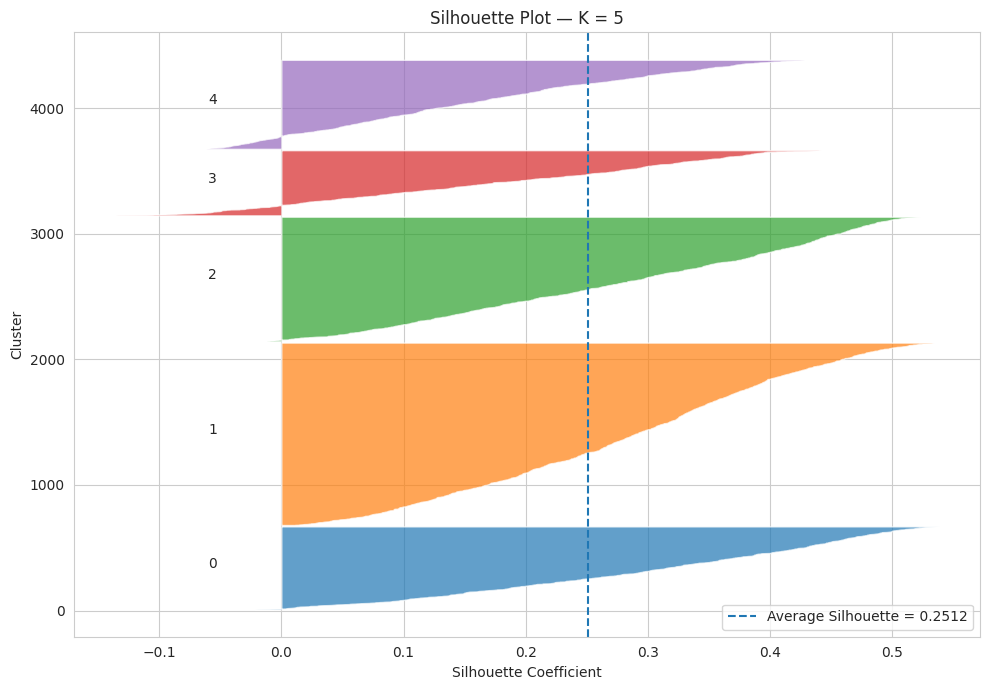

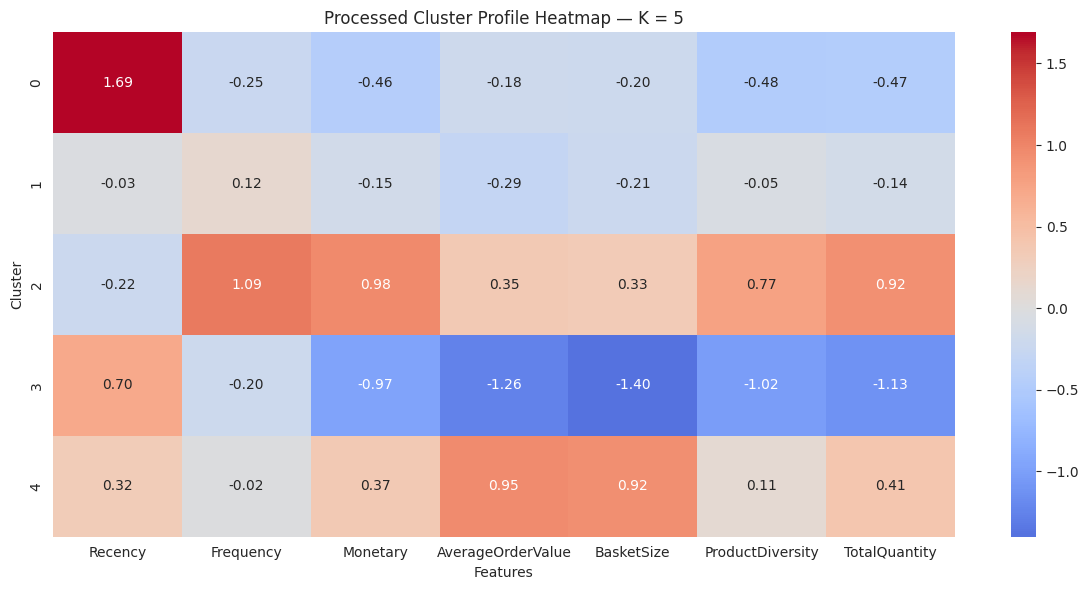

K=5 completed | Silhouette=0.2512 | DBI=1.2230 | CH=1755.97

PROCESSING K = 6
K=6 completed | Silhouette=0.2338 | DBI=1.1735 | CH=1666.53

PROCESSING K = 7
K=7 completed | Silhouette=0.2211 | DBI=1.2051 | CH=1565.76

PROCESSING K = 8
K=8 completed | Silhouette=0.2201 | DBI=1.2057 | CH=1474.84

PROCESSING K = 9
K=9 completed | Silhouette=0.2181 | DBI=1.1835 | CH=1416.62

PROCESSING K = 10
K=10 completed | Silhouette=0.2176 | DBI=1.2015 | CH=1359.77


In [ ]:
validation_results = []
cluster_balance_results = []
seed_stability_results = []
subsample_stability_results = []
all_cluster_size_tables = []
all_silhouette_summaries = []

models_by_k = {}
labels_by_k = {}
mean_profiles_by_k = {}
median_profiles_by_k = {}

for k in K_VALUES:

    print("\n" + "=" * 90)
    print(f"PROCESSING K = {k}")
    print("=" * 90)

    # --------------------------------------------------------
    # Baseline model
    # --------------------------------------------------------

    baseline_model = build_kmeans(
        k=k,
        random_state=BASELINE_RANDOM_STATE
    )

    labels = baseline_model.fit_predict(X)

    models_by_k[k] = baseline_model
    labels_by_k[k] = labels

    # --------------------------------------------------------
    # Internal validation
    # --------------------------------------------------------

    silhouette = silhouette_score(X, labels)
    dbi = davies_bouldin_score(X, labels)
    ch = calinski_harabasz_score(X, labels)

    validation_results.append({
        "K": k,
        "WCSS_Inertia": baseline_model.inertia_,
        "Silhouette_Score": silhouette,
        "Davies_Bouldin_Index": dbi,
        "Calinski_Harabasz_Index": ch,
        "Iterations_to_Converge": baseline_model.n_iter_
    })

    # --------------------------------------------------------
    # Save model and assignments
    # --------------------------------------------------------

    joblib.dump(
        baseline_model,
        MODELS_DIR / f"kmeans_model_k_{k}.joblib"
    )

    processed_clustered = processed_data.copy()
    processed_clustered["Cluster"] = labels

    raw_clustered = raw_data.copy()
    raw_clustered["Cluster"] = labels

    processed_clustered.to_csv(
        DATASETS_DIR / f"processed_clustered_k_{k}.csv",
        index=False
    )

    raw_clustered.to_csv(
        DATASETS_DIR / f"original_scale_clustered_k_{k}.csv",
        index=False
    )

    # --------------------------------------------------------
    # Cluster size and feasibility
    # --------------------------------------------------------

    cluster_size = create_cluster_size_table(
        labels=labels,
        k=k
    )

    cluster_size.insert(0, "K", k)
    all_cluster_size_tables.append(cluster_size)

    smallest_percentage = (
        cluster_size["Customer_Percentage"].min()
    )

    cluster_balance_results.append({
        "K": k,
        "Smallest_Cluster_Count": (
            cluster_size["Customer_Count"].min()
        ),
        "Largest_Cluster_Count": (
            cluster_size["Customer_Count"].max()
        ),
        "Smallest_Cluster_Percentage": (
            smallest_percentage
        ),
        "Largest_Cluster_Percentage": (
            cluster_size["Customer_Percentage"].max()
        ),
        "Largest_to_Smallest_Ratio": (
            cluster_size["Customer_Count"].max()
            / cluster_size["Customer_Count"].min()
        ),
        "All_Clusters_At_Least_5_Percent": (
            smallest_percentage
            >= MINIMUM_PRACTICAL_CLUSTER_PERCENTAGE
        )
    })

    cluster_size.to_csv(
        TABLES_DIR / f"cluster_size_k_{k}.csv",
        index=False
    )

    # --------------------------------------------------------
    # Original-scale profiles
    # --------------------------------------------------------

    mean_profile = (
        raw_clustered
        .groupby("Cluster")[FEATURE_COLUMNS]
        .mean()
        .round(2)
    )

    median_profile = (
        raw_clustered
        .groupby("Cluster")[FEATURE_COLUMNS]
        .median()
        .round(2)
    )

    standard_deviation_profile = (
        raw_clustered
        .groupby("Cluster")[FEATURE_COLUMNS]
        .std()
        .round(2)
    )

    mean_profiles_by_k[k] = mean_profile.copy()
    median_profiles_by_k[k] = median_profile.copy()

    mean_profile.to_csv(
        PROFILES_DIR / f"mean_profile_k_{k}.csv"
    )

    median_profile.to_csv(
        PROFILES_DIR / f"median_profile_k_{k}.csv"
    )

    standard_deviation_profile.to_csv(
        PROFILES_DIR / f"standard_deviation_profile_k_{k}.csv"
    )

    # --------------------------------------------------------
    # Per-customer and per-cluster silhouette values
    # --------------------------------------------------------

    individual_silhouette = silhouette_samples(
        X,
        labels
    )

    silhouette_summary = create_silhouette_summary(
        labels=labels,
        silhouette_values=individual_silhouette,
        k=k
    )

    silhouette_summary.insert(0, "K", k)
    all_silhouette_summaries.append(
        silhouette_summary
    )

    silhouette_summary.to_csv(
        TABLES_DIR / f"cluster_silhouette_summary_k_{k}.csv",
        index=False
    )

    # --------------------------------------------------------
    # Random-seed stability
    # --------------------------------------------------------

    seed_run_results = []

    for seed in SEED_VALUES:
        seed_model = build_kmeans(
            k=k,
            random_state=seed
        )

        seed_labels = seed_model.fit_predict(X)

        seed_run_results.append({
            "K": k,
            "Random_State": seed,
            "Adjusted_Rand_Index": adjusted_rand_score(
                labels,
                seed_labels
            ),
            "Inertia": seed_model.inertia_,
            "Iterations": seed_model.n_iter_
        })

    seed_runs = pd.DataFrame(seed_run_results)

    seed_runs.to_csv(
        STABILITY_DIR / f"random_seed_runs_k_{k}.csv",
        index=False
    )

    seed_stability_results.append({
        "K": k,
        "Seed_Runs": len(seed_runs),
        "Mean_Seed_ARI": (
            seed_runs["Adjusted_Rand_Index"].mean()
        ),
        "Median_Seed_ARI": (
            seed_runs["Adjusted_Rand_Index"].median()
        ),
        "Minimum_Seed_ARI": (
            seed_runs["Adjusted_Rand_Index"].min()
        ),
        "Maximum_Seed_ARI": (
            seed_runs["Adjusted_Rand_Index"].max()
        ),
        "Seed_ARI_Standard_Deviation": (
            seed_runs["Adjusted_Rand_Index"].std()
        ),
        "Perfect_Seed_Matches": (
            seed_runs["Adjusted_Rand_Index"] == 1
        ).sum()
    })

    # --------------------------------------------------------
    # Repeated 80% subsampling stability
    # --------------------------------------------------------

    random_generator = np.random.default_rng(
        SUBSAMPLE_RANDOM_STATE + k
    )

    sample_size = int(
        len(X) * SUBSAMPLE_FRACTION
    )

    subsample_run_results = []

    for run_number in range(1, SUBSAMPLE_RUNS + 1):
        sampled_positions = random_generator.choice(
            len(X),
            size=sample_size,
            replace=False
        )

        sampled_positions = np.sort(sampled_positions)

        X_subsample = X.iloc[sampled_positions]
        baseline_labels_for_sample = labels[
            sampled_positions
        ]

        subsample_model = build_kmeans(
            k=k,
            random_state=(
                SUBSAMPLE_RANDOM_STATE
                + k * 100
                + run_number
            )
        )

        subsample_labels = (
            subsample_model.fit_predict(
                X_subsample
            )
        )

        subsample_run_results.append({
            "K": k,
            "Run": run_number,
            "Sample_Size": sample_size,
            "Sample_Fraction": SUBSAMPLE_FRACTION,
            "Adjusted_Rand_Index": adjusted_rand_score(
                baseline_labels_for_sample,
                subsample_labels
            ),
            "Inertia": subsample_model.inertia_,
            "Iterations": subsample_model.n_iter_
        })

    subsample_runs = pd.DataFrame(
        subsample_run_results
    )

    subsample_runs.to_csv(
        STABILITY_DIR / f"subsampling_runs_k_{k}.csv",
        index=False
    )

    subsample_stability_results.append({
        "K": k,
        "Subsample_Runs": SUBSAMPLE_RUNS,
        "Sample_Fraction": SUBSAMPLE_FRACTION,
        "Sample_Size": sample_size,
        "Mean_Subsample_ARI": (
            subsample_runs["Adjusted_Rand_Index"].mean()
        ),
        "Median_Subsample_ARI": (
            subsample_runs["Adjusted_Rand_Index"].median()
        ),
        "Minimum_Subsample_ARI": (
            subsample_runs["Adjusted_Rand_Index"].min()
        ),
        "Maximum_Subsample_ARI": (
            subsample_runs["Adjusted_Rand_Index"].max()
        ),
        "Subsample_ARI_Standard_Deviation": (
            subsample_runs["Adjusted_Rand_Index"].std()
        )
    })

    # --------------------------------------------------------
    # PCA plot
    # --------------------------------------------------------

    pca_clustered = pca_base.copy()
    pca_clustered["Cluster"] = labels

    pca_clustered.to_csv(
        DATASETS_DIR / f"pca_clustered_k_{k}.csv",
        index=False
    )

    plt.figure(figsize=(10, 7))

    sns.scatterplot(
        data=pca_clustered,
        x="PC1",
        y="PC2",
        hue="Cluster",
        palette="tab10",
        alpha=0.65,
        s=40
    )

    plt.title(f"PCA Customer Segments — K = {k}")
    plt.xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)"
    )
    plt.ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)"
    )
    plt.legend(
        title="Cluster",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"pca_clusters_k_{k}.png",
        dpi=300,
        bbox_inches="tight"
    )

    if k in CANDIDATE_K_VALUES:
        plt.show()
    else:
        plt.close()

    # --------------------------------------------------------
    # Silhouette plot
    # --------------------------------------------------------

    plt.figure(figsize=(10, 7))
    y_lower = 10

    for cluster_number in range(k):
        cluster_values = individual_silhouette[
            labels == cluster_number
        ]

        cluster_values.sort()
        cluster_count = cluster_values.shape[0]
        y_upper = y_lower + cluster_count

        plt.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            cluster_values,
            alpha=0.70
        )

        plt.text(
            -0.06,
            y_lower + 0.5 * cluster_count,
            str(cluster_number)
        )

        y_lower = y_upper + 10

    plt.axvline(
        silhouette,
        linestyle="--",
        label=f"Average Silhouette = {silhouette:.4f}"
    )

    plt.title(f"Silhouette Plot — K = {k}")
    plt.xlabel("Silhouette Coefficient")
    plt.ylabel("Cluster")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"silhouette_plot_k_{k}.png",
        dpi=300,
        bbox_inches="tight"
    )

    if k in CANDIDATE_K_VALUES:
        plt.show()
    else:
        plt.close()

    # --------------------------------------------------------
    # Relative profile heatmap
    # --------------------------------------------------------

    scaled_profile = (
        processed_clustered
        .groupby("Cluster")[FEATURE_COLUMNS]
        .mean()
    )

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        scaled_profile,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(f"Processed Cluster Profile Heatmap — K = {k}")
    plt.xlabel("Features")
    plt.ylabel("Cluster")
    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / f"processed_profile_heatmap_k_{k}.png",
        dpi=300,
        bbox_inches="tight"
    )

    if k in CANDIDATE_K_VALUES:
        plt.show()
    else:
        plt.close()

    print(
        f"K={k} completed | "
        f"Silhouette={silhouette:.4f} | "
        f"DBI={dbi:.4f} | "
        f"CH={ch:.2f}"
    )

## 10. Create the overall validation table



In [ ]:
validation_df = pd.DataFrame(
    validation_results
).sort_values("K").reset_index(drop=True)

validation_df["WCSS_Reduction_Percentage"] = (
    validation_df["WCSS_Inertia"]
    .pct_change()
    .abs()
    * 100
)

validation_df["Silhouette_Rank"] = (
    validation_df["Silhouette_Score"]
    .rank(
        ascending=False,
        method="min"
    )
)

validation_df["Davies_Bouldin_Rank"] = (
    validation_df["Davies_Bouldin_Index"]
    .rank(
        ascending=True,
        method="min"
    )
)

validation_df["Calinski_Harabasz_Rank"] = (
    validation_df["Calinski_Harabasz_Index"]
    .rank(
        ascending=False,
        method="min"
    )
)

validation_df["Average_Internal_Validation_Rank"] = (
    validation_df[
        [
            "Silhouette_Rank",
            "Davies_Bouldin_Rank",
            "Calinski_Harabasz_Rank"
        ]
    ]
    .mean(axis=1)
)

validation_df = validation_df.round(4)

validation_ranked = (
    validation_df
    .sort_values(
        [
            "Average_Internal_Validation_Rank",
            "Silhouette_Rank"
        ]
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("INTERNAL VALIDATION RESULTS")
print("=" * 80)

display(validation_df)

print("\nRanked internal validation:")
display(validation_ranked)

validation_df.to_csv(
    TABLES_DIR / "all_k_internal_validation.csv",
    index=False
)

validation_ranked.to_csv(
    TABLES_DIR / "all_k_internal_validation_ranked.csv",
    index=False
)

INTERNAL VALIDATION RESULTS


,K,WCSS_Inertia,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,Iterations_to_Converge,WCSS_Reduction_Percentage,Silhouette_Rank,Davies_Bouldin_Rank,Calinski_Harabasz_Rank,Average_Internal_Validation_Rank
0,2,"11,101.9913",0.3262,1.1444,"2,692.5260",8,NaN,1.0000,1.0000,1.0000,1.0000
1,3,"9,093.9108",0.2493,1.2964,"2,121.7776",13,18.0876,4.0000,9.0000,2.0000,5.0000
2,4,"7,860.4640",0.2522,1.2088,"1,862.8098",19,13.5634,2.0000,7.0000,3.0000,4.0000
3,5,"6,866.0351",0.2512,1.2230,"1,755.9685",37,12.6510,3.0000,8.0000,4.0000,5.0000
4,6,"6,155.6332",0.2338,1.1735,"1,666.5317",24,10.3466,5.0000,2.0000,5.0000,4.0000
5,7,"5,678.4958",0.2211,1.2051,"1,565.7640",30,7.7512,6.0000,5.0000,6.0000,5.6667
6,8,"5,317.5527",0.2201,1.2057,"1,474.8426",43,6.3563,7.0000,6.0000,7.0000,6.6667
7,9,"4,974.1588",0.2181,1.1835,"1,416.6163",28,6.4577,8.0000,3.0000,8.0000,6.3333
8,10,"4,701.6076",0.2176,1.2015,"1,359.7734",32,5.4793,9.0000,4.0000,9.0000,7.3333



Ranked internal validation:


,K,WCSS_Inertia,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,Iterations_to_Converge,WCSS_Reduction_Percentage,Silhouette_Rank,Davies_Bouldin_Rank,Calinski_Harabasz_Rank,Average_Internal_Validation_Rank
0,2,"11,101.9913",0.3262,1.1444,"2,692.5260",8,NaN,1.0000,1.0000,1.0000,1.0000
1,4,"7,860.4640",0.2522,1.2088,"1,862.8098",19,13.5634,2.0000,7.0000,3.0000,4.0000
2,6,"6,155.6332",0.2338,1.1735,"1,666.5317",24,10.3466,5.0000,2.0000,5.0000,4.0000
3,5,"6,866.0351",0.2512,1.2230,"1,755.9685",37,12.6510,3.0000,8.0000,4.0000,5.0000
4,3,"9,093.9108",0.2493,1.2964,"2,121.7776",13,18.0876,4.0000,9.0000,2.0000,5.0000
5,7,"5,678.4958",0.2211,1.2051,"1,565.7640",30,7.7512,6.0000,5.0000,6.0000,5.6667
6,9,"4,974.1588",0.2181,1.1835,"1,416.6163",28,6.4577,8.0000,3.0000,8.0000,6.3333
7,8,"5,317.5527",0.2201,1.2057,"1,474.8426",43,6.3563,7.0000,6.0000,7.0000,6.6667
8,10,"4,701.6076",0.2176,1.2015,"1,359.7734",32,5.4793,9.0000,4.0000,9.0000,7.3333


## 11. Create stability and cluster-feasibility summaries

In [ ]:
seed_stability_df = pd.DataFrame(
    seed_stability_results
).round(4)

subsample_stability_df = pd.DataFrame(
    subsample_stability_results
).round(4)

cluster_balance_df = pd.DataFrame(
    cluster_balance_results
).round(4)

all_cluster_sizes_df = pd.concat(
    all_cluster_size_tables,
    ignore_index=True
).round(4)

all_silhouette_summaries_df = pd.concat(
    all_silhouette_summaries,
    ignore_index=True
).round(4)

print("Random-seed stability:")
display(seed_stability_df)

print("\nSubsampling stability:")
display(subsample_stability_df)

print("\nCluster-size feasibility:")
display(cluster_balance_df)

seed_stability_df.to_csv(
    STABILITY_DIR / "all_k_random_seed_stability_summary.csv",
    index=False
)

subsample_stability_df.to_csv(
    STABILITY_DIR / "all_k_subsampling_stability_summary.csv",
    index=False
)

cluster_balance_df.to_csv(
    TABLES_DIR / "all_k_cluster_feasibility_summary.csv",
    index=False
)

all_cluster_sizes_df.to_csv(
    TABLES_DIR / "all_k_cluster_sizes.csv",
    index=False
)

all_silhouette_summaries_df.to_csv(
    TABLES_DIR / "all_k_per_cluster_silhouette_summary.csv",
    index=False
)

Random-seed stability:


,K,Seed_Runs,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Perfect_Seed_Matches
0,2,30,1.0000,1.0000,1.0000,1.0000,0.0000,30
1,3,30,0.9995,1.0000,0.9971,1.0000,0.0011,24
2,4,30,0.9984,0.9993,0.9901,1.0000,0.0024,10
3,5,30,0.9999,1.0000,0.9996,1.0000,0.0002,23
4,6,30,0.9580,0.9582,0.9327,0.9957,0.0115,0
5,7,30,0.9847,0.9949,0.8799,1.0000,0.0335,1
6,8,30,0.9480,0.9571,0.8957,0.9959,0.0344,0
7,9,30,0.9736,0.9751,0.9533,1.0000,0.0130,1
8,10,30,0.9624,0.9627,0.9108,1.0000,0.0233,1



Subsampling stability:


,K,Subsample_Runs,Sample_Fraction,Sample_Size,Mean_Subsample_ARI,Median_Subsample_ARI,Minimum_Subsample_ARI,Maximum_Subsample_ARI,Subsample_ARI_Standard_Deviation
0,2,50,0.8000,3470,0.9875,0.9879,0.9702,1.0000,0.0077
1,3,50,0.8000,3470,0.9760,0.9846,0.9108,0.9982,0.0230
2,4,50,0.8000,3470,0.9394,0.9655,0.5239,0.9952,0.0995
3,5,50,0.8000,3470,0.9557,0.9588,0.8729,0.9955,0.0228
4,6,50,0.8000,3470,0.8719,0.9234,0.7058,0.9703,0.0927
5,7,50,0.8000,3470,0.7302,0.8369,0.4908,0.9853,0.1938
6,8,50,0.8000,3470,0.7517,0.8426,0.4251,0.9454,0.1700
7,9,50,0.8000,3470,0.7624,0.8113,0.4674,0.9545,0.1552
8,10,50,0.8000,3470,0.7655,0.8263,0.4902,0.9547,0.1590



Cluster-size feasibility:


,K,Smallest_Cluster_Count,Largest_Cluster_Count,Smallest_Cluster_Percentage,Largest_Cluster_Percentage,Largest_to_Smallest_Ratio,All_Clusters_At_Least_5_Percent
0,2,2043,2295,47.0954,52.9046,1.1233,True
1,3,979,2039,22.5680,47.0032,2.0827,True
2,4,682,1741,15.7215,40.1337,2.5528,True
3,5,520,1454,11.9871,33.5178,2.7962,True
4,6,380,1056,8.7598,24.3430,2.7789,True
5,7,334,979,7.6994,22.5680,2.9311,True
6,8,224,834,5.1637,19.2254,3.7232,True
7,9,177,786,4.0802,18.1189,4.4407,False
8,10,103,743,2.3744,17.1277,7.2136,False


In [ ]:
complete_evidence = (
    validation_df
    .merge(
        seed_stability_df,
        on="K",
        how="left"
    )
    .merge(
        subsample_stability_df,
        on="K",
        how="left"
    )
    .merge(
        cluster_balance_df,
        on="K",
        how="left"
    )
)

complete_evidence["Mean_Seed_ARI_Rank"] = (
    complete_evidence["Mean_Seed_ARI"]
    .rank(
        ascending=False,
        method="min"
    )
)

complete_evidence["Mean_Subsample_ARI_Rank"] = (
    complete_evidence["Mean_Subsample_ARI"]
    .rank(
        ascending=False,
        method="min"
    )
)

complete_evidence["Average_Stability_Rank"] = (
    complete_evidence[
        [
            "Mean_Seed_ARI_Rank",
            "Mean_Subsample_ARI_Rank"
        ]
    ]
    .mean(axis=1)
)

complete_evidence = complete_evidence.round(4)

display(complete_evidence)

complete_evidence.to_csv(
    TABLES_DIR / "complete_k_evidence_table.csv",
    index=False
)

,K,WCSS_Inertia,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,Iterations_to_Converge,WCSS_Reduction_Percentage,Silhouette_Rank,Davies_Bouldin_Rank,Calinski_Harabasz_Rank,Average_Internal_Validation_Rank,Seed_Runs,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Perfect_Seed_Matches,Subsample_Runs,Sample_Fraction,Sample_Size,Mean_Subsample_ARI,Median_Subsample_ARI,Minimum_Subsample_ARI,Maximum_Subsample_ARI,Subsample_ARI_Standard_Deviation,Smallest_Cluster_Count,Largest_Cluster_Count,Smallest_Cluster_Percentage,Largest_Cluster_Percentage,Largest_to_Smallest_Ratio,All_Clusters_At_Least_5_Percent,Mean_Seed_ARI_Rank,Mean_Subsample_ARI_Rank,Average_Stability_Rank
0,2,"11,101.9913",0.3262,1.1444,"2,692.5260",8,NaN,1.0000,1.0000,1.0000,1.0000,30,1.0000,1.0000,1.0000,1.0000,0.0000,30,50,0.8000,3470,0.9875,0.9879,0.9702,1.0000,0.0077,2043,2295,47.0954,52.9046,1.1233,True,1.0000,1.0000,1.0000
1,3,"9,093.9108",0.2493,1.2964,"2,121.7776",13,18.0876,4.0000,9.0000,2.0000,5.0000,30,0.9995,1.0000,0.9971,1.0000,0.0011,24,50,0.8000,3470,0.9760,0.9846,0.9108,0.9982,0.0230,979,2039,22.5680,47.0032,2.0827,True,3.0000,2.0000,2.5000
2,4,"7,860.4640",0.2522,1.2088,"1,862.8098",19,13.5634,2.0000,7.0000,3.0000,4.0000,30,0.9984,0.9993,0.9901,1.0000,0.0024,10,50,0.8000,3470,0.9394,0.9655,0.5239,0.9952,0.0995,682,1741,15.7215,40.1337,2.5528,True,4.0000,4.0000,4.0000
3,5,"6,866.0351",0.2512,1.2230,"1,755.9685",37,12.6510,3.0000,8.0000,4.0000,5.0000,30,0.9999,1.0000,0.9996,1.0000,0.0002,23,50,0.8000,3470,0.9557,0.9588,0.8729,0.9955,0.0228,520,1454,11.9871,33.5178,2.7962,True,2.0000,3.0000,2.5000
4,6,"6,155.6332",0.2338,1.1735,"1,666.5317",24,10.3466,5.0000,2.0000,5.0000,4.0000,30,0.9580,0.9582,0.9327,0.9957,0.0115,0,50,0.8000,3470,0.8719,0.9234,0.7058,0.9703,0.0927,380,1056,8.7598,24.3430,2.7789,True,8.0000,5.0000,6.5000
5,7,"5,678.4958",0.2211,1.2051,"1,565.7640",30,7.7512,6.0000,5.0000,6.0000,5.6667,30,0.9847,0.9949,0.8799,1.0000,0.0335,1,50,0.8000,3470,0.7302,0.8369,0.4908,0.9853,0.1938,334,979,7.6994,22.5680,2.9311,True,5.0000,9.0000,7.0000
6,8,"5,317.5527",0.2201,1.2057,"1,474.8426",43,6.3563,7.0000,6.0000,7.0000,6.6667,30,0.9480,0.9571,0.8957,0.9959,0.0344,0,50,0.8000,3470,0.7517,0.8426,0.4251,0.9454,0.1700,224,834,5.1637,19.2254,3.7232,True,9.0000,8.0000,8.5000
7,9,"4,974.1588",0.2181,1.1835,"1,416.6163",28,6.4577,8.0000,3.0000,8.0000,6.3333,30,0.9736,0.9751,0.9533,1.0000,0.0130,1,50,0.8000,3470,0.7624,0.8113,0.4674,0.9545,0.1552,177,786,4.0802,18.1189,4.4407,False,6.0000,7.0000,6.5000
8,10,"4,701.6076",0.2176,1.2015,"1,359.7734",32,5.4793,9.0000,4.0000,9.0000,7.3333,30,0.9624,0.9627,0.9108,1.0000,0.0233,1,50,0.8000,3470,0.7655,0.8263,0.4902,0.9547,0.1590,103,743,2.3744,17.1277,7.2136,False,7.0000,6.0000,6.5000


## 13. Plot the overall comparison metrics

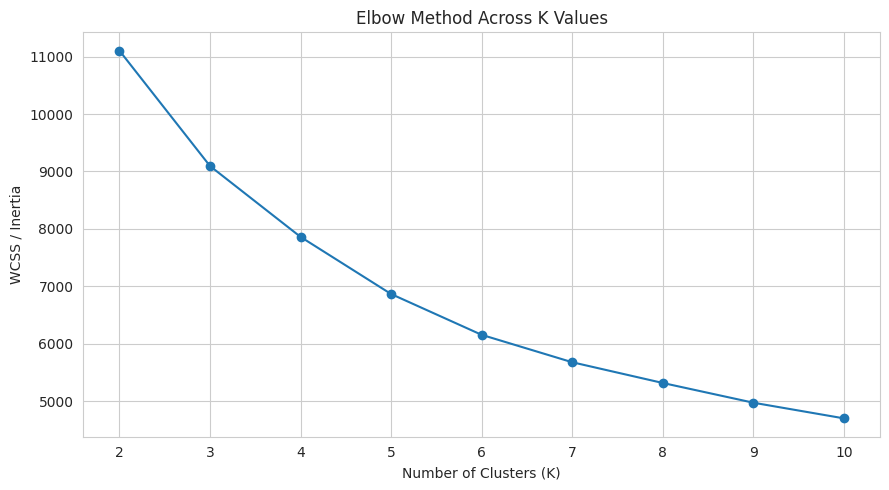

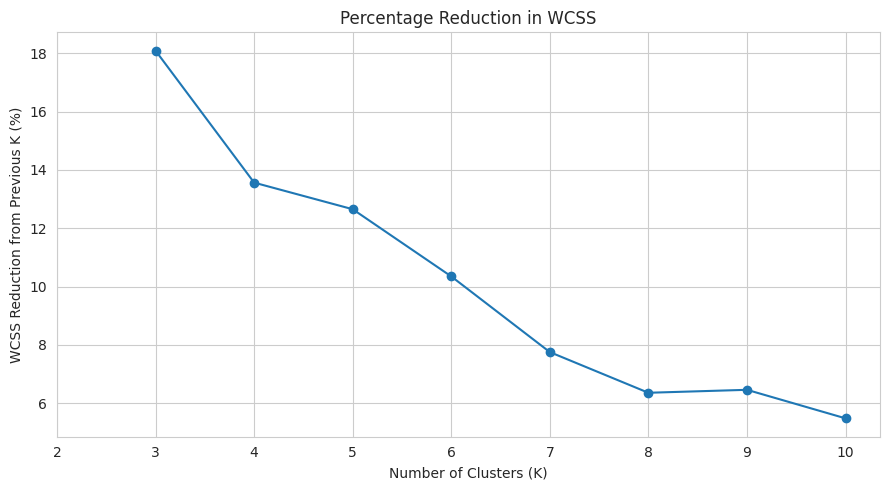

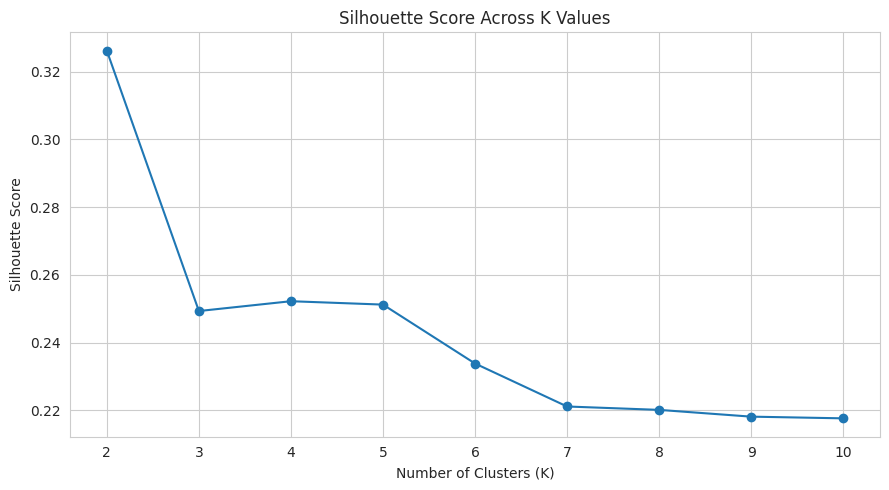

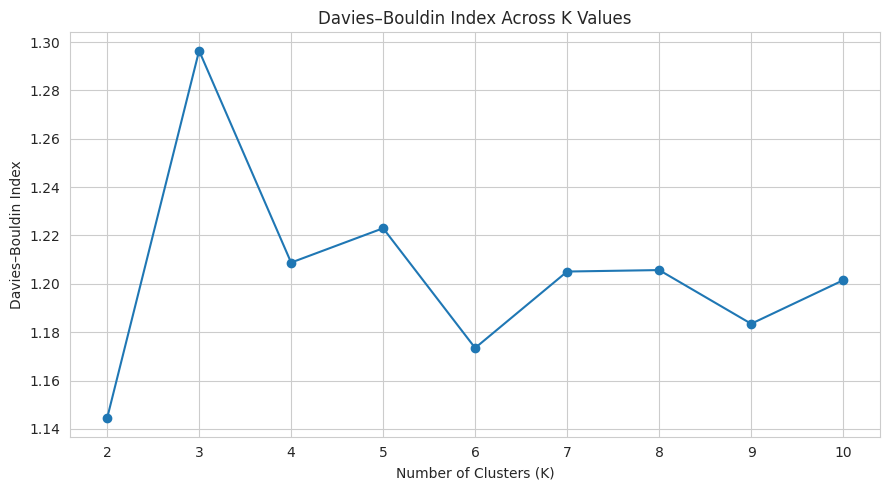

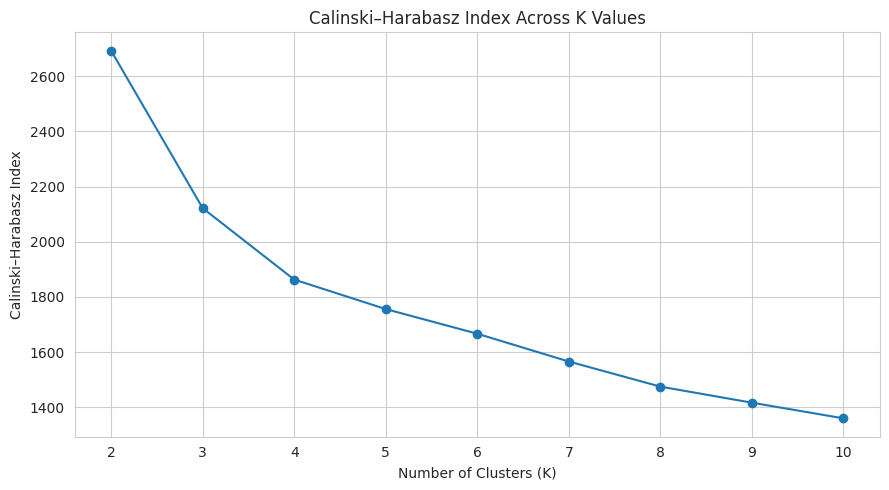

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(
    validation_df["K"],
    validation_df["WCSS_Inertia"],
    marker="o"
)
plt.title("Elbow Method Across K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS / Inertia")
plt.xticks(K_VALUES)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "comparison_elbow_curve.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    validation_df["K"],
    validation_df["WCSS_Reduction_Percentage"],
    marker="o"
)
plt.title("Percentage Reduction in WCSS")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS Reduction from Previous K (%)")
plt.xticks(K_VALUES)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "comparison_wcss_reduction.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    validation_df["K"],
    validation_df["Silhouette_Score"],
    marker="o"
)
plt.title("Silhouette Score Across K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(K_VALUES)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "comparison_silhouette_scores.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    validation_df["K"],
    validation_df["Davies_Bouldin_Index"],
    marker="o"
)
plt.title("Davies–Bouldin Index Across K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Davies–Bouldin Index")
plt.xticks(K_VALUES)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "comparison_davies_bouldin.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(
    validation_df["K"],
    validation_df["Calinski_Harabasz_Index"],
    marker="o"
)
plt.title("Calinski–Harabasz Index Across K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Calinski–Harabasz Index")
plt.xticks(K_VALUES)
plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "comparison_calinski_harabasz.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## 14. Plot stability and cluster-size feasibility

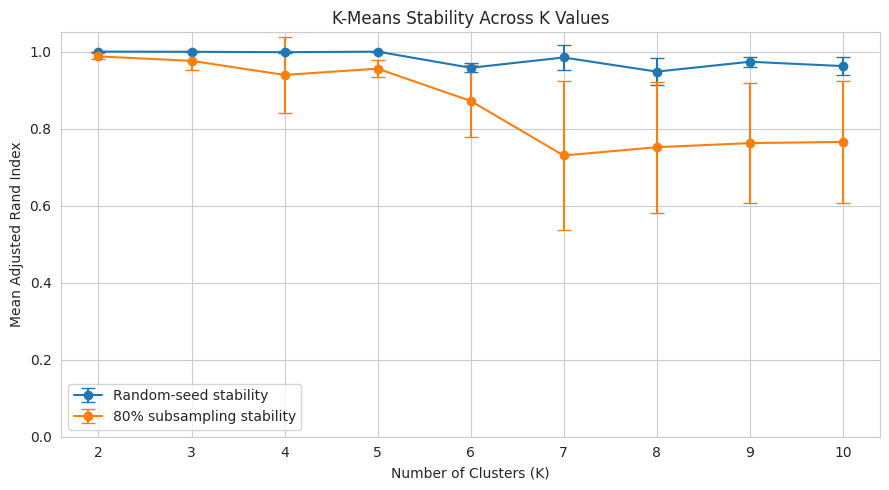

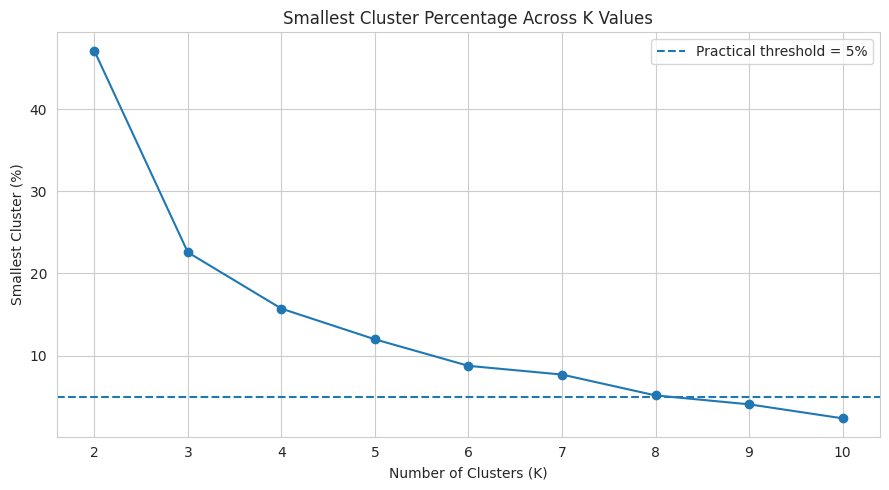

In [ ]:
plt.figure(figsize=(9, 5))

plt.errorbar(
    seed_stability_df["K"],
    seed_stability_df["Mean_Seed_ARI"],
    yerr=seed_stability_df[
        "Seed_ARI_Standard_Deviation"
    ],
    marker="o",
    capsize=5,
    label="Random-seed stability"
)

plt.errorbar(
    subsample_stability_df["K"],
    subsample_stability_df["Mean_Subsample_ARI"],
    yerr=subsample_stability_df[
        "Subsample_ARI_Standard_Deviation"
    ],
    marker="o",
    capsize=5,
    label="80% subsampling stability"
)

plt.title("K-Means Stability Across K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Mean Adjusted Rand Index")
plt.xticks(K_VALUES)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "comparison_stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(9, 5))

plt.plot(
    cluster_balance_df["K"],
    cluster_balance_df[
        "Smallest_Cluster_Percentage"
    ],
    marker="o"
)

plt.axhline(
    MINIMUM_PRACTICAL_CLUSTER_PERCENTAGE,
    linestyle="--",
    label=(
        f"Practical threshold = "
        f"{MINIMUM_PRACTICAL_CLUSTER_PERCENTAGE:.0f}%"
    )
)

plt.title("Smallest Cluster Percentage Across K Values")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Smallest Cluster (%)")
plt.xticks(K_VALUES)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "comparison_smallest_cluster_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Compare K=2, K=3, K=4 and K=5



In [ ]:
candidate_evidence = (
    complete_evidence[
        complete_evidence["K"].isin(
            CANDIDATE_K_VALUES
        )
    ]
    .copy()
    .reset_index(drop=True)
)

candidate_evidence["Statistical_Benchmark"] = False
candidate_evidence["Operational_Candidate"] = (
    candidate_evidence["K"] == OPERATIONAL_K
)

best_statistical_k = int(
    validation_ranked.iloc[0]["K"]
)

candidate_evidence.loc[
    candidate_evidence["K"] == best_statistical_k,
    "Statistical_Benchmark"
] = True

display(candidate_evidence)

candidate_evidence.to_csv(
    CANDIDATE_DIR / "candidate_evidence_table.csv",
    index=False
)

,K,WCSS_Inertia,Silhouette_Score,Davies_Bouldin_Index,Calinski_Harabasz_Index,Iterations_to_Converge,WCSS_Reduction_Percentage,Silhouette_Rank,Davies_Bouldin_Rank,Calinski_Harabasz_Rank,Average_Internal_Validation_Rank,Seed_Runs,Mean_Seed_ARI,Median_Seed_ARI,Minimum_Seed_ARI,Maximum_Seed_ARI,Seed_ARI_Standard_Deviation,Perfect_Seed_Matches,Subsample_Runs,Sample_Fraction,Sample_Size,Mean_Subsample_ARI,Median_Subsample_ARI,Minimum_Subsample_ARI,Maximum_Subsample_ARI,Subsample_ARI_Standard_Deviation,Smallest_Cluster_Count,Largest_Cluster_Count,Smallest_Cluster_Percentage,Largest_Cluster_Percentage,Largest_to_Smallest_Ratio,All_Clusters_At_Least_5_Percent,Mean_Seed_ARI_Rank,Mean_Subsample_ARI_Rank,Average_Stability_Rank,Statistical_Benchmark,Operational_Candidate
0,2,"11,101.9913",0.3262,1.1444,"2,692.5260",8,NaN,1.0000,1.0000,1.0000,1.0000,30,1.0000,1.0000,1.0000,1.0000,0.0000,30,50,0.8000,3470,0.9875,0.9879,0.9702,1.0000,0.0077,2043,2295,47.0954,52.9046,1.1233,True,1.0000,1.0000,1.0000,True,False
1,3,"9,093.9108",0.2493,1.2964,"2,121.7776",13,18.0876,4.0000,9.0000,2.0000,5.0000,30,0.9995,1.0000,0.9971,1.0000,0.0011,24,50,0.8000,3470,0.9760,0.9846,0.9108,0.9982,0.0230,979,2039,22.5680,47.0032,2.0827,True,3.0000,2.0000,2.5000,False,False
2,4,"7,860.4640",0.2522,1.2088,"1,862.8098",19,13.5634,2.0000,7.0000,3.0000,4.0000,30,0.9984,0.9993,0.9901,1.0000,0.0024,10,50,0.8000,3470,0.9394,0.9655,0.5239,0.9952,0.0995,682,1741,15.7215,40.1337,2.5528,True,4.0000,4.0000,4.0000,False,False
3,5,"6,866.0351",0.2512,1.2230,"1,755.9685",37,12.6510,3.0000,8.0000,4.0000,5.0000,30,0.9999,1.0000,0.9996,1.0000,0.0002,23,50,0.8000,3470,0.9557,0.9588,0.8729,0.9955,0.0228,520,1454,11.9871,33.5178,2.7962,True,2.0000,3.0000,2.5000,False,True


## 16. Combine candidate mean and median profiles

In [ ]:
candidate_mean_tables = []
candidate_median_tables = []

for k in CANDIDATE_K_VALUES:
    mean_table = (
        mean_profiles_by_k[k]
        .reset_index()
    )
    mean_table.insert(0, "K", k)
    candidate_mean_tables.append(mean_table)

    median_table = (
        median_profiles_by_k[k]
        .reset_index()
    )
    median_table.insert(0, "K", k)
    candidate_median_tables.append(median_table)

candidate_mean_profiles = pd.concat(
    candidate_mean_tables,
    ignore_index=True
)

candidate_median_profiles = pd.concat(
    candidate_median_tables,
    ignore_index=True
)

print("Candidate mean profiles:")
display(candidate_mean_profiles)

print("\nCandidate median profiles:")
display(candidate_median_profiles)

candidate_mean_profiles.to_csv(
    CANDIDATE_DIR / "candidate_mean_profiles.csv",
    index=False
)

candidate_median_profiles.to_csv(
    CANDIDATE_DIR / "candidate_median_profiles.csv",
    index=False
)

Candidate mean profiles:


,K,Cluster,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,2,0,48.7600,6.5300,"3,578.3600",599.8500,373.9000,96.8200,"2,090.2700"
1,2,1,141.7100,1.7300,330.3300,212.9600,116.0400,21.8200,173.6800
2,3,0,177.4800,1.5800,214.2700,149.7000,67.6900,13.7100,95.0200
3,3,1,89.1100,2.3400,660.1500,334.9300,205.4900,40.0900,391.1100
4,3,2,34.8300,9.2500,"5,554.0800",744.1400,462.0700,130.0200,"3,228.4100"
5,4,0,36.5300,9.4100,"5,930.8200",797.1600,495.0000,133.0500,"3,454.7900"
6,4,1,48.3700,2.9300,741.1800,296.3600,182.1900,46.7300,432.8800
7,4,2,256.5100,1.4100,474.3500,364.1200,210.4000,24.9500,266.5600
8,4,3,138.2500,1.6000,186.5100,123.3100,54.1700,11.5600,80.1700
9,5,0,260.6700,1.4100,362.0600,276.1700,148.8800,21.3400,190.5900



Candidate median profiles:


,K,Cluster,Recency,Frequency,Monetary,AverageOrderValue,BasketSize,ProductDiversity,TotalQuantity
0,2,0,27.0000,4.0000,"1,555.3400",387.0800,241.5000,70.0000,919.0000
1,2,1,110.0000,1.0000,294.1200,182.9800,96.0000,17.0000,150.0000
2,3,0,184.0000,1.0000,175.2000,133.5600,63.5000,10.0000,84.0000
3,3,1,57.0000,2.0000,592.9700,298.2100,167.0000,32.0000,330.0000
4,3,2,19.0000,6.0000,"2,612.3600",430.6100,267.8800,99.0000,"1,566.0000"
5,4,0,20.0000,6.0000,"2,780.6500",460.7400,284.0600,101.0000,"1,674.0000"
6,4,1,37.0000,2.0000,654.6700,264.8800,153.0000,37.0000,368.0000
7,4,2,256.5000,1.0000,358.4700,308.4000,155.5000,20.0000,196.5000
8,4,3,119.0000,1.0000,149.0500,114.0000,49.0000,8.0000,70.0000
9,5,0,262.0000,1.0000,311.5500,251.8000,128.0000,17.0000,156.0000


## 17. Review per-cluster silhouette quality for the candidates

In [ ]:
candidate_silhouette_summary = (
    all_silhouette_summaries_df[
        all_silhouette_summaries_df["K"].isin(
            CANDIDATE_K_VALUES
        )
    ]
    .copy()
    .reset_index(drop=True)
)

display(candidate_silhouette_summary)

candidate_silhouette_summary.to_csv(
    CANDIDATE_DIR / "candidate_per_cluster_silhouette_summary.csv",
    index=False
)

,K,Cluster,Customer_Count,Mean_Silhouette,Median_Silhouette,Minimum_Silhouette,Maximum_Silhouette,Standard_Deviation,Negative_Silhouette_Customers,Negative_Silhouette_Percentage
0,2,0,2295,0.3539,0.3822,0.0054,0.5499,0.1433,0,0.0000
1,2,1,2043,0.2951,0.3269,-0.0490,0.5075,0.1414,49,2.3984
2,3,0,979,0.2180,0.2387,-0.0822,0.4472,0.1409,84,8.5802
3,3,1,2039,0.2497,0.2483,0.0018,0.4720,0.1152,0,0.0000
4,3,2,1320,0.2718,0.3009,-0.0285,0.4837,0.1421,23,1.7424
5,4,0,1204,0.2334,0.2589,-0.0866,0.4596,0.1474,112,9.3023
6,4,1,1741,0.2839,0.2894,0.0312,0.5132,0.1178,0,0.0000
7,4,2,682,0.2607,0.2679,-0.0412,0.5080,0.1459,27,3.9589
8,4,3,711,0.1986,0.2144,-0.0865,0.4533,0.1485,95,13.3615
9,5,0,661,0.2991,0.3149,-0.0219,0.5380,0.1461,5,0.7564


## 18. Exploratory Kruskal–Wallis tests with effect sizes



In [ ]:
kruskal_results = []

for k in CANDIDATE_K_VALUES:
    labels = labels_by_k[k]

    for feature in FEATURE_COLUMNS:
        groups = [
            raw_data.loc[
                labels == cluster_number,
                feature
            ].dropna().to_numpy()
            for cluster_number in range(k)
        ]

        h_statistic, p_value = kruskal(*groups)

        effect_size = epsilon_squared_kruskal(
            h_statistic=h_statistic,
            n=len(raw_data),
            number_of_groups=k
        )

        kruskal_results.append({
            "K": k,
            "Feature": feature,
            "Kruskal_H": h_statistic,
            "P_Value": p_value,
            "Epsilon_Squared": effect_size,
            "Exploratory_Only": True
        })

kruskal_results_df = pd.DataFrame(
    kruskal_results
).round(6)

display(kruskal_results_df)

kruskal_results_df.to_csv(
    CANDIDATE_DIR / "candidate_kruskal_wallis_effect_sizes.csv",
    index=False
)

,K,Feature,Kruskal_H,P_Value,Epsilon_Squared,Exploratory_Only
0,2,Recency,933.4254,0.0000,0.2150,True
1,2,Frequency,"1,599.1474",0.0000,0.3686,True
2,2,Monetary,"2,901.0365",0.0000,0.6688,True
3,2,AverageOrderValue,"1,564.4250",0.0000,0.3606,True
4,2,BasketSize,"1,591.6031",0.0000,0.3668,True
5,2,ProductDiversity,"1,979.8591",0.0000,0.4564,True
6,2,TotalQuantity,"3,008.3322",0.0000,0.6936,True
7,3,Recency,"1,131.8282",0.0000,0.2606,True
8,3,Frequency,"2,056.3155",0.0000,0.4739,True
9,3,Monetary,"3,318.7332",0.0000,0.7651,True


## 19. Decision summary

This notebook gives us the two distinct statements:

- **Statistical benchmark:** the K with the strongest combined internal validation evidence.
- **Operational candidate:** K=5,  which retained for detailed business interpretation if its stability and cluster-size feasibility remain acceptable.

so the  operational choice will be justified using profiles and business usefulness.

In [ ]:
statistical_row = validation_df.loc[
    validation_df["K"] == best_statistical_k
].iloc[0]

operational_row = complete_evidence.loc[
    complete_evidence["K"] == OPERATIONAL_K
].iloc[0]

decision_summary = pd.DataFrame({
    "Decision_Role": [
        "Statistical benchmark",
        "Operational candidate"
    ],
    "K": [
        best_statistical_k,
        OPERATIONAL_K
    ],
    "Reason": [
        (
            "Strongest combined internal validation evidence "
            "across Silhouette, Davies–Bouldin and "
            "Calinski–Harabasz metrics."
        ),
        (
            "Selected for detailed business interpretation "
            "because it provides five customer groups while "
            "retaining acceptable validation, strong stability "
            "and practical cluster sizes."
        )
    ]
})

display(decision_summary)

decision_summary.to_csv(
    TABLES_DIR / "k_selection_decision_summary.csv",
    index=False
)

print(
    f"Statistical benchmark: K={best_statistical_k} | "
    f"Silhouette={statistical_row['Silhouette_Score']:.4f}"
)

print(
    f"Operational candidate: K={OPERATIONAL_K} | "
    f"Silhouette={operational_row['Silhouette_Score']:.4f} | "
    f"Mean subsampling ARI="
    f"{operational_row['Mean_Subsample_ARI']:.4f} | "
    f"Smallest cluster="
    f"{operational_row['Smallest_Cluster_Percentage']:.2f}%"
)

,Decision_Role,K,Reason
0,Statistical benchmark,2,Strongest combined internal validation evidenc...
1,Operational candidate,5,Selected for detailed business interpretation ...


Statistical benchmark: K=2 | Silhouette=0.3262
Operational candidate: K=5 | Silhouette=0.2512 | Mean subsampling ARI=0.9557 | Smallest cluster=11.99%


## 20.  summary

In [ ]:
operational_is_feasible = bool(
    operational_row[
        "All_Clusters_At_Least_5_Percent"
    ]
)

supervisor_summary = f'''
COMPLETE K-MEANS EVALUATION SUMMARY

Dataset:
- Customers: {len(X)}
- Features: {len(FEATURE_COLUMNS)}
- Tested K values: {K_VALUES}

Method:
- K-Means++ initialisation
- n_init = {BASELINE_N_INIT}
- max_iter = {MAX_ITER}
- Random-seed stability runs per K = {len(SEED_VALUES)}
- 80% subsampling runs per K = {SUBSAMPLE_RUNS}

Statistical benchmark:
- K = {best_statistical_k}
- Silhouette Score = {statistical_row["Silhouette_Score"]:.4f}
- Davies-Bouldin Index = {statistical_row["Davies_Bouldin_Index"]:.4f}
- Calinski-Harabasz Index = {statistical_row["Calinski_Harabasz_Index"]:.2f}

Operational candidate:
- K = {OPERATIONAL_K}
- Silhouette Score = {operational_row["Silhouette_Score"]:.4f}
- Davies-Bouldin Index = {operational_row["Davies_Bouldin_Index"]:.4f}
- Calinski-Harabasz Index = {operational_row["Calinski_Harabasz_Index"]:.2f}
- Mean random-seed ARI = {operational_row["Mean_Seed_ARI"]:.4f}
- Mean 80% subsampling ARI = {operational_row["Mean_Subsample_ARI"]:.4f}
- Minimum 80% subsampling ARI = {operational_row["Minimum_Subsample_ARI"]:.4f}
- Smallest cluster = {operational_row["Smallest_Cluster_Percentage"]:.2f}%
- All clusters meet 5% feasibility threshold = {operational_is_feasible}

Interpretation:
The statistically strongest K is reported openly as the benchmark.
K=5 is not claimed to be the mathematical winner. It is retained as
the operational candidate because it provides greater business
granularity while maintaining acceptable internal validation, strong
stability and practical cluster sizes.

Limitations:
- Internal validation metrics evaluate related aspects of compactness
  and separation and should not be treated as independent votes.
- Cluster-size balance is a feasibility check rather than proof that
  equally sized clusters are better.
- Kruskal-Wallis tests are exploratory because the same features were
  used to create the clusters.
- Correlated features may give related purchasing dimensions additional
  influence in Euclidean distance.
'''.strip()

with open(
    RESULTS_DIR / "supervisor_evaluation_summary.txt",
    "w"
) as file:
    file.write(supervisor_summary)

print(supervisor_summary)

COMPLETE K-MEANS EVALUATION SUMMARY

Dataset:
- Customers: 4338
- Features: 7
- Tested K values: [2, 3, 4, 5, 6, 7, 8, 9, 10]

Method:
- K-Means++ initialisation
- n_init = 50
- max_iter = 500
- Random-seed stability runs per K = 30
- 80% subsampling runs per K = 50

Statistical benchmark:
- K = 2
- Silhouette Score = 0.3262
- Davies-Bouldin Index = 1.1444
- Calinski-Harabasz Index = 2692.53

Operational candidate:
- K = 5
- Silhouette Score = 0.2512
- Davies-Bouldin Index = 1.2230
- Calinski-Harabasz Index = 1755.97
- Mean random-seed ARI = 0.9999
- Mean 80% subsampling ARI = 0.9557
- Minimum 80% subsampling ARI = 0.8729
- Smallest cluster = 11.99%
- All clusters meet 5% feasibility threshold = True

Interpretation:
The statistically strongest K is reported openly as the benchmark.
K=5 is not claimed to be the mathematical winner. It is retained as
the operational candidate because it provides greater business
granularity while maintaining acceptable internal validation, strong
stabil

## 21. Create the final ZIP archive

In [ ]:
zip_path = shutil.make_archive(
    base_name="/content/KMeans_Complete_Evaluation_Updated_Results",
    format="zip",
    root_dir=RESULTS_DIR
)

print("=" * 80)
print("COMPLETE K-MEANS EVALUATION FINISHED")
print("=" * 80)

print("\nMain result folder:")
print(RESULTS_DIR)

print("\nZIP archive:")
print(zip_path)

print("\nImportant files:")
print("1. all_k_internal_validation.csv")
print("2. all_k_random_seed_stability_summary.csv")
print("3. all_k_subsampling_stability_summary.csv")
print("4. all_k_cluster_feasibility_summary.csv")
print("5. all_k_per_cluster_silhouette_summary.csv")
print("6. candidate_evidence_table.csv")
print("7. candidate_mean_profiles.csv")
print("8. candidate_median_profiles.csv")
print("9. candidate_kruskal_wallis_effect_sizes.csv")
print("10. k_selection_decision_summary.csv")
print("11. supervisor_evaluation_summary.txt")

COMPLETE K-MEANS EVALUATION FINISHED

Main result folder:
/content/KMeans_Complete_Evaluation_Updated_Results

ZIP archive:
/content/KMeans_Complete_Evaluation_Updated_Results.zip

Important files:
1. all_k_internal_validation.csv
2. all_k_random_seed_stability_summary.csv
3. all_k_subsampling_stability_summary.csv
4. all_k_cluster_feasibility_summary.csv
5. all_k_per_cluster_silhouette_summary.csv
6. candidate_evidence_table.csv
7. candidate_mean_profiles.csv
8. candidate_median_profiles.csv
9. candidate_kruskal_wallis_effect_sizes.csv
10. k_selection_decision_summary.csv
11. supervisor_evaluation_summary.txt
